![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/banner_1.png)

# Taller: Construcción e implementación de modelos Bagging, Random Forest y XGBoost

En este taller podrán poner en práctica sus conocimientos sobre la construcción e implementación de modelos de Bagging, Random Forest y XGBoost. El taller está constituido por 8 puntos, en los cuales deberan seguir las intrucciones de cada numeral para su desarrollo.

## Datos predicción precio de automóviles

En este taller se usará el conjunto de datos de Car Listings de Kaggle donde cada observación representa el precio de un automóvil teniendo en cuenta distintas variables como año, marca, modelo, entre otras. El objetivo es predecir el precio del automóvil. Para más detalles puede visitar el siguiente enlace: [datos](https://www.kaggle.com/jpayne/852k-used-car-listings).

In [84]:
import warnings
warnings.filterwarnings('ignore')

In [85]:
# Importación de librerías
%matplotlib inline
import numpy as np
import pandas as pd


# Lectura de la información de archivo .csv
data = pd.read_csv('https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/datasets/dataTrain_carListings.zip')

# Preprocesamiento de datos para el taller
data = data.loc[data['Model'].str.contains('Camry')].drop(['Make', 'State'], axis=1)
data = data.join(pd.get_dummies(data['Model'], prefix='M'))
data = data.drop(['Model'], axis=1)

# Visualización dataset
data.head()

,Price,Year,Mileage,M_Camry,M_Camry4dr,M_CamryBase,M_CamryL,M_CamryLE,M_CamrySE,M_CamryXLE
7,21995,2014,6480,False,False,False,True,False,False,False
11,13995,2014,39972,False,False,False,False,True,False,False
167,17941,2016,18989,False,False,False,False,False,True,False
225,12493,2014,51330,False,False,False,True,False,False,False
270,7994,2007,116065,False,True,False,False,False,False,False


In [86]:
# Separación de variables predictoras (X) y variable de interés (y)
y = data['Price']
X = data.drop(['Price'], axis=1)

In [87]:
# Separación de datos en set de entrenamiento y test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=23)

### Punto 1 - Árbol de decisión manual

En la celda 1 creen un árbol de decisión **manualmente**  que considere los set de entrenamiento y test definidos anteriormente y presenten el RMSE y MAE del modelo en el set de test.

In [88]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Celda 1

# Función para calcular la reducción de varianza
def variance(y):
    return np.var(y) if len(y) > 0 else 0

# Función para calcular la reducción de varianza después de una división
def variance_reduction(X_col, y, split):
    filter_l = X_col < split
    y_l = y.loc[filter_l]
    y_r = y.loc[~filter_l]

    n_l, n_r = len(y_l), len(y_r)
    if n_l == 0 or n_r == 0:  # Evitar divisiones vacías
        return 0

    var_y = variance(y)
    var_l = variance(y_l)
    var_r = variance(y_r)

    return var_y - (n_l / (n_l + n_r) * var_l + n_r / (n_l + n_r) * var_r)

# Función para encontrar la mejor división
def best_split(X, y, num_pct=10):
    features = range(X.shape[1])
    best_split = [None, None, float('-inf')]  

    for j in features:
        splits = np.percentile(X.iloc[:, j].astype(float), np.linspace(0, 100, num_pct+2)[1:-1])
        splits = np.unique(splits)

        for split in splits:
            gain = variance_reduction(X.iloc[:, j], y, split)

            if gain > best_split[2]:  # Guardar mejor división
                best_split = [j, split, gain]

    if best_split[0] is None:  # Si no se encontró una mejor división
        return [0, 0, 0]

    return best_split

# Crecimiento recursivo del árbol de regresión
def tree_grow(X, y, level=0, min_gain=0.001, max_depth=None, num_pct=10):
    if X.shape[0] == 1:
        return dict(y_pred=y.iloc[0], level=level, split=-1, n_samples=1, gain=0)

    j, split, gain = best_split(X, y, num_pct)
    y_pred = y.mean()

    tree = dict(y_pred=y_pred, level=level, split=-1, n_samples=len(y), gain=gain)

    if gain < min_gain or (max_depth is not None and level >= max_depth):
        return tree

    filter_l = X.iloc[:, j] < split
    X_l, y_l = X.loc[filter_l], y.loc[filter_l]
    X_r, y_r = X.loc[~filter_l], y.loc[~filter_l]

    if len(y_l) == 0 or len(y_r) == 0:  # Manejar el caso de divisiones vacías
        return tree

    tree['split'] = [j, split]
    tree['sl'] = tree_grow(X_l, y_l, level + 1, min_gain, max_depth, num_pct)
    tree['sr'] = tree_grow(X_r, y_r, level + 1, min_gain, max_depth, num_pct)

    return tree

# Definición de la función para predecir 
def tree_predict(tree, X_row):
    while 'split' in tree and tree['split'] != -1:
        j, split = tree['split']
        if X_row[j] < split:
            tree = tree['sl']
        else:
            tree = tree['sr']
    return tree['y_pred']

# Aplicación del modelo
tree_1 = tree_grow(X_train, y_train, level=0, min_gain=0.001, max_depth=3, num_pct=10)

# Predicciones
y_pred = X_test.apply(lambda row: tree_predict(tree_1, row), axis=1)

# Evaluación del modelo
rmse_manual_tree = np.sqrt(mean_squared_error(y_test, y_pred))
mae__manual_tree = mean_absolute_error(y_test, y_pred)

print(f"RMSE: {rmse_manual_tree:.4f}")
print(f"MAE: {mae__manual_tree:.4f}")




RMSE: 1950.2015
MAE: 1460.3471


### Punto 2 - Bagging manual

En la celda 2 creen un modelo bagging **manualmente** con 10 árboles de regresión y comenten sobre el desempeño del modelo.

In [89]:
# Celda 2
# Parámetros iniciales del modelo
num_trees = 10
trees = []

for _ in range(num_trees):
    # Muestreo bootstrap asegurando que los índices coincidan
    X_bootstrap = X_train.sample(frac=1, replace=True, random_state=23)
    y_bootstrap = y_train.loc[X_bootstrap.index]  # Asegurar que los índices coincidan
    
    # Entrenar árbol
    tree_model = tree_grow(X_bootstrap, y_bootstrap, level=0, min_gain=0.001, max_depth=3, num_pct=10)
    trees.append(tree_model)

# **Predicción con bagging**
def bagging_predict(trees, X_test):
    predictions = np.array([np.array([tree_predict(tree, row) for _, row in X_test.iterrows()]) for tree in trees])
    return predictions.mean(axis=0)  # Promedio de predicciones

Y_pred_bagging = bagging_predict(trees, X_test)

# **Evaluación**
rmse_manual_bagging = np.sqrt(mean_squared_error(y_test, Y_pred_bagging))
mae_manual_bagging = mean_absolute_error(y_test, Y_pred_bagging)

print(f"Bagging RMSE: {rmse_manual_bagging:.4f}")
print(f"Bagging MAE: {mae_manual_bagging:.4f}")


Bagging RMSE: 1955.2954
Bagging MAE: 1466.8367


### Punto 3 - Bagging con librería

En la celda 3, con la librería sklearn, entrenen un modelo bagging con 10 árboles de regresión y el parámetro `max_features` del árbol de decisión igual a `log(n_features)` y comenten sobre el desempeño del modelo.

In [90]:
# Celda 3
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
# Parámetro `max_features` como logaritmo del número de características
n_features = X_train.shape[1]
max_features = int(np.log(n_features))  # Conversión a entero

# Configuración del modelo BaggingRegressor
bagreg = BaggingRegressor(
    estimator=DecisionTreeRegressor(),
    n_estimators=10,
    max_features=max_features,
    bootstrap=True,
    oob_score=True,
    random_state=23
)

# Entrenamiento del modelo
bagreg.fit(X_train, y_train)

# Predicción en el conjunto de prueba
y_pred = bagreg.predict(X_test)

# Cálculo de métricas
rmse_bagging = np.sqrt(mean_squared_error(y_test, y_pred))
mae_bagging = mean_absolute_error(y_test, y_pred)

print(f"Bagging RMSE: {rmse_bagging:.4f}")
print(f"Bagging MAE: {mae_bagging:.4f}")

# Evaluación del error out-of-bag (R²)
print(f"Out-of-Bag Score (R²): {bagreg.oob_score_:.4f}")

Bagging RMSE: 2988.2798
Bagging MAE: 2290.7644
Out-of-Bag Score (R²): 0.2229


### Punto 4 - Random forest con librería

En la celda 4, usando la librería sklearn entrenen un modelo de Random Forest para regresión  y comenten sobre el desempeño del modelo.

In [91]:
# Celda 4
from sklearn.ensemble import RandomForestRegressor

n_features = X_train.shape[1]
max_features = int(np.log(n_features))  # Conversión a entero

# Configuración del modelo Random Forest
rf_model = RandomForestRegressor(
    n_estimators=10,           # Número de árboles
    max_features=max_features,  # Subconjunto de características por árbol
    bootstrap=True,            # Muestreo con reemplazo
    oob_score=True,            # Evaluación out-of-bag
    random_state=23
)

# Entrenamiento del modelo
rf_model.fit(X_train, y_train)

# Predicción en el conjunto de prueba
y_pred_rf = rf_model.predict(X_test)

# Cálculo de métricas
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print(f"Random Forest RMSE: {rmse_rf:.4f}")
print(f"Random Forest MAE: {mae_rf:.4f}")

# Evaluación del error out-of-bag (R²)
print(f"Out-of-Bag Score (R²): {rf_model.oob_score_:.4f}")

Random Forest RMSE: 1821.3502
Random Forest MAE: 1359.5410
Out-of-Bag Score (R²): 0.6043


### Punto 5 - Calibración de parámetros Random forest

En la celda 5, calibren los parámetros max_depth, max_features y n_estimators del modelo de Random Forest para regresión, comenten sobre el desempeño del modelo y describan cómo cada parámetro afecta el desempeño del modelo.

In [92]:
# Celda 5
from sklearn.model_selection import GridSearchCV
# Matriz de parámetros a optimizar
param_grid = {
    'max_depth': list(range(1, 15)),  
    'max_features': list(range(1, X_train.shape[1] + 1)),  
    'n_estimators': list(range(5, 100, 5))  # De 5 a 100 árboles en pasos de 5
}
# Random Forest Model
rf_model = RandomForestRegressor(bootstrap=True, oob_score=True, random_state=23)

# 5 fold cross-validation
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Mejores parámetros
best_params = grid_search.best_params_
print(f"Best Parameters: {best_params}")

# Entrenar modelo con mejores parámetros
rf_best = RandomForestRegressor(**best_params, bootstrap=True, oob_score=True, random_state=23)
rf_best.fit(X_train, y_train)

# Predicciones en el conjunto de prueba
y_pred_best = rf_best.predict(X_test)

# Evaluation
rmse_best_rf = np.sqrt(mean_squared_error(y_test, y_pred_best))
mae_best_rf = mean_absolute_error(y_test, y_pred_best)

print(f"Optimized Random Forest RMSE: {rmse_best_rf:.4f}")
print(f"Optimized Random Forest MAE: {mae_best_rf:.4f}")
print(f"Optimized Out-of-Bag Score (R²): {rf_best.oob_score_:.4f}")

Best Parameters: {'max_depth': 8, 'max_features': 4, 'n_estimators': 85}
Optimized Random Forest RMSE: 1557.8180
Optimized Random Forest MAE: 1146.6633
Optimized Out-of-Bag Score (R²): 0.8480


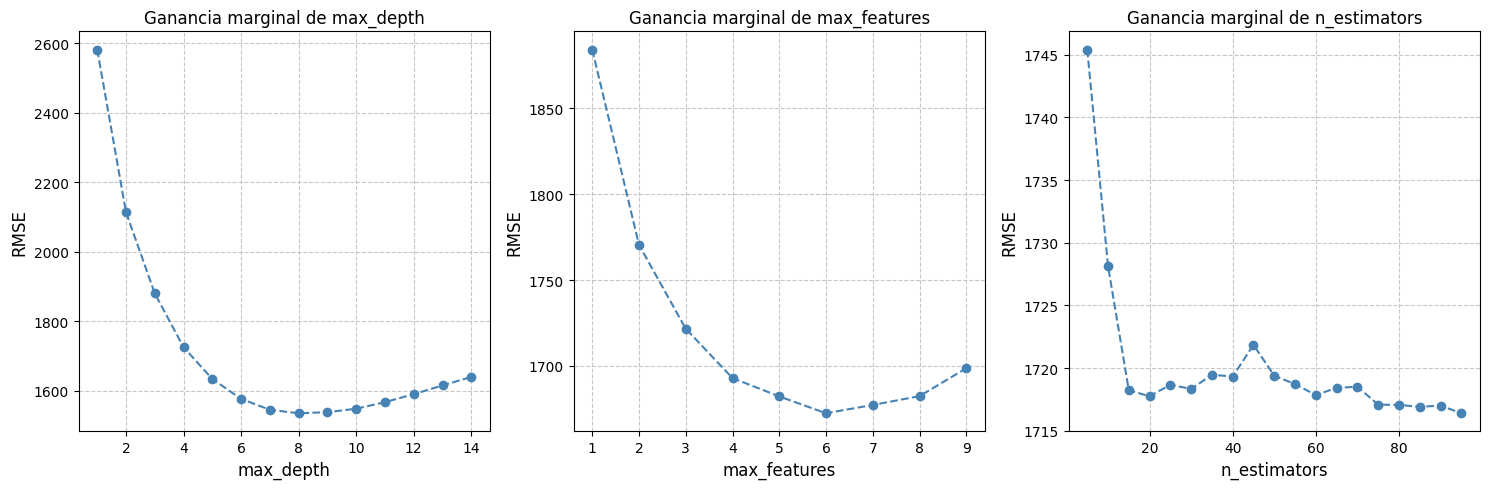

In [93]:
import matplotlib.pyplot as plt

# Extraer resultados de la búsqueda en GridSearchCV
results = grid_search.cv_results_
params_tested = results['params']
scores = -results['mean_test_score']  
rmse_scores = np.sqrt(scores)

# Graficar la ganancia marginal por hiperparámetro
fig, axes = plt.subplots(1, 3, figsize=(15, 5))  
param_names = list(param_grid.keys())

for i, param in enumerate(param_names):
    param_values = sorted(set([p[param] for p in params_tested]))  
    param_rmse = [
        np.mean([rmse_scores[j] for j in range(len(params_tested)) if params_tested[j][param] == val])
        for val in param_values
    ]  # Calcular promedio de RMSE por valor del hiperparámetro

    axes[i].plot(param_values, param_rmse, marker='o', linestyle='--', color='steelblue')  
    axes[i].set_title(f'Ganancia marginal de {param}', fontsize=12)
    axes[i].set_xlabel(param, fontsize=12)
    axes[i].set_ylabel('RMSE', fontsize=12)
    axes[i].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


### Punto 6 - XGBoost con librería

En la celda 6 implementen un modelo XGBoost de regresión con la librería sklearn y comenten sobre el desempeño del modelo.

In [94]:
# Celda 6
from xgboost import XGBRegressor

# Configuración del modelo XGBoost
xgb_model = XGBRegressor()

# Entrenamiento del modelo
xgb_model.fit(X_train, y_train)

# Predicción en el conjunto de prueba
y_pred_xgb = xgb_model.predict(X_test)

# Cálculo de métricas
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)

print(f"XGBoost RMSE: {rmse_xgb:.4f}")
print(f"XGBoost MAE: {mae_xgb:.4f}")

XGBoost RMSE: 1608.6703
XGBoost MAE: 1186.3165


### Punto 7 - Calibración de parámetros XGBoost

En la celda 7 calibren los parámetros learning rate, gamma y colsample_bytree del modelo XGBoost para regresión, comenten sobre el desempeño del modelo y describan cómo cada parámetro afecta el desempeño del modelo.

Mejores parámetros encontrados: {'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.05}
XGBoost óptimo RMSE: 1541.0375
XGBoost óptimo MAE: 1131.5718


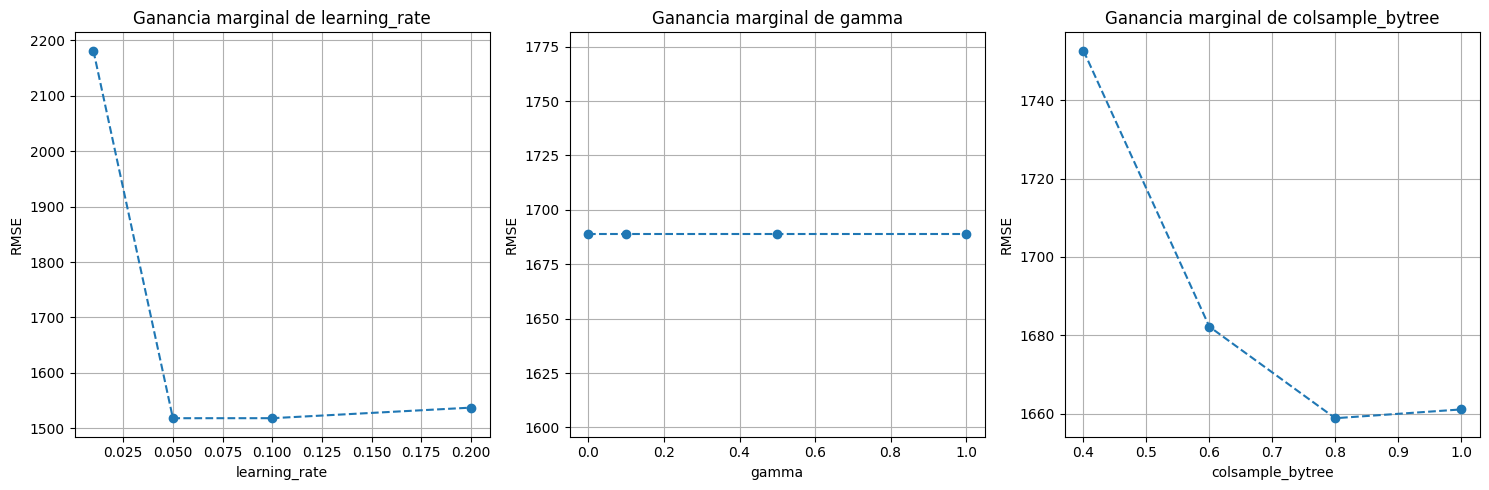

In [95]:
# Celda 7
# Definir la cuadrícula de hiperparámetros
param_grid = {
    'learning_rate': [0.01, 0.05, 0.1, 0.2],  # Tasa de aprendizaje
    'gamma': [0, 0.1, 0.5, 1],                # Penalización de pérdida
    'colsample_bytree': [0.4, 0.6, 0.8, 1.0]       # Porcentaje de características por árbol
}

# Configuración del modelo base
xgb_model = XGBRegressor(random_state=23)

# Grid Search para encontrar los mejores hiperparámetros
grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Obtener los mejores parámetros
best_params = grid_search.best_params_
print(f"Mejores parámetros encontrados: {best_params}")

# Entrenar modelo con mejores parámetros
xgb_best = XGBRegressor(**best_params, random_state=23)
xgb_best.fit(X_train, y_train)

# Predicciones en el conjunto de prueba
y_pred_best = xgb_best.predict(X_test)

# Evaluación del modelo
rmse_best_xgb = np.sqrt(mean_squared_error(y_test, y_pred_best))
mae_best_xgb = mean_absolute_error(y_test, y_pred_best)

print(f"XGBoost óptimo RMSE: {rmse_best_xgb:.4f}")
print(f"XGBoost óptimo MAE: {mae_best_xgb:.4f}")

# Graficar la ganancia marginal por hiperparámetro
results = grid_search.cv_results_
params_tested = results['params']
scores = -results['mean_test_score']  # Convertir a positivo para calcular RMSE
rmse_scores = np.sqrt(scores)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))  # 1 fila, 3 columnas
param_names = list(param_grid.keys())

for i, param in enumerate(param_names):
    param_values = sorted(set([p[param] for p in params_tested]))
    param_rmse = [np.mean([rmse_scores[j] for j in range(len(params_tested)) if params_tested[j][param] == val]) for val in param_values]

    axes[i].plot(param_values, param_rmse, marker='o', linestyle='--')
    axes[i].set_title(f'Ganancia marginal de {param}')
    axes[i].set_xlabel(param)
    axes[i].set_ylabel('RMSE')
    axes[i].grid(True)

plt.tight_layout()
plt.show()

### Punto 8 - Comparación y análisis de resultados
En la celda 8 comparen los resultados obtenidos de los diferentes modelos (random forest y XGBoost) y comenten las ventajas del mejor modelo y las desventajas del modelo con el menor desempeño.

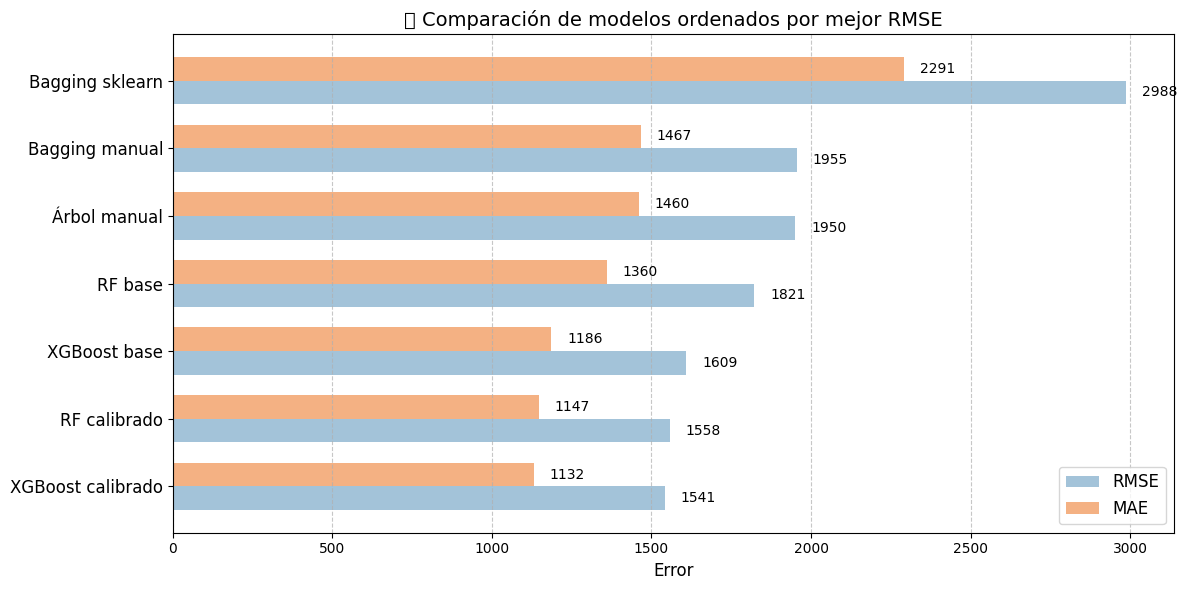

In [96]:
# Celda 8

# Definir nombres de modelos y métricas obtenidas
modelos = ['Árbol manual','Bagging manual', 'Bagging sklearn','RF base','RF calibrado','XGBoost base','XGBoost calibrado']
rmse = [rmse_manual_tree,rmse_manual_bagging,rmse_bagging,rmse_rf,rmse_best_rf,rmse_xgb,rmse_best_xgb] 
mae = [mae__manual_tree,mae_manual_bagging,mae_bagging,mae_rf,mae_best_rf,mae_xgb,mae_best_xgb]  

# Crear DataFrame con los resultados
df_resultados = pd.DataFrame({
    'Modelo': modelos,
    'RMSE': rmse,
    'MAE': mae
})

# Ordenar por RMSE ascendente (mejor desempeño primero)
df_resultados = df_resultados.sort_values(by='RMSE')
y_pos = np.arange(len(df_resultados))


plt.figure(figsize=(12, 6))
bar_width = 0.35  # Espaciado de barras
bars1 = plt.barh(y_pos - bar_width/2, df_resultados['RMSE'], height=bar_width, label='RMSE', color='#a3c3d9')  # Azul pastel
bars2 = plt.barh(y_pos + bar_width/2, df_resultados['MAE'], height=bar_width, label='MAE', color='#f4b183')  # Naranja pastel

# Etiquetas en barras
for bar in bars1:
    plt.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2, f'{bar.get_width():.0f}', va='center', fontsize=10)
for bar in bars2:
    plt.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2, f'{bar.get_width():.0f}', va='center', fontsize=10)

plt.yticks(y_pos, df_resultados['Modelo'], fontsize=12)
plt.xlabel('Error', fontsize=12)
plt.title('📊 Comparación de modelos ordenados por mejor RMSE', fontsize=14)
plt.legend(fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

